# **(EDA) Eploratory Data Analysis for the hotel bookings dataset.**






# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load dataset**

In [2]:
data=pd.read_csv('/content/first inten project.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [3]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


# **Data Preprocessing**

In [4]:
#  merge the number of weekend nights	and number of week nights	in asingle column

data['Total_nights'] = data['number of weekend nights'] + data['number of week nights']
data.drop(['number of weekend nights', 'number of week nights'], axis=1, inplace=True)

In [5]:
#  merge the number of adults	and number of children in a single column

data['number of guests'] = data['number of adults'] + data['number of children']
data.drop(['number of adults', 'number of children'], axis=1, inplace=True)

In [6]:
#Check for Duplicates
data.duplicated().sum()

0

In [7]:
# Remove rows where the 'repeated' column is not equal to 0
data = data[data['repeated'] == 0]

In [8]:
data.drop('repeated',axis=1,inplace=True)

<ipython-input-8-b304968af185>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('repeated',axis=1,inplace=True)


In [9]:
#Drop Unnecessary Columns
columns_to_drop = ["Booking_ID", "P-C", "P-not-C"]
data.drop(columns=columns_to_drop, inplace=True)

<ipython-input-9-af5d3dc7d20b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=columns_to_drop, inplace=True)


In [10]:
print(data.columns) # it turns out 'average price ' had a space

Index(['type of meal', 'car parking space', 'room type', 'lead time',
       'market segment type', 'average price ', 'special requests',
       'date of reservation', 'booking status', 'Total_nights',
       'number of guests'],
      dtype='object')


In [11]:
#Rename column to remove space
data.rename(columns={'average price ': 'average price'}, inplace=True)
data['average price'] = data['average price'].astype('int64') #convert it to intgers

<ipython-input-11-313c062a8a58>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns={'average price ': 'average price'}, inplace=True)


In [12]:
# Step 3: Convert to datetime with the correct format
data['date of reservation'] = pd.to_datetime(data['date of reservation'], format='%Y-%m-%d', errors='coerce')

# **Visuals**

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been as

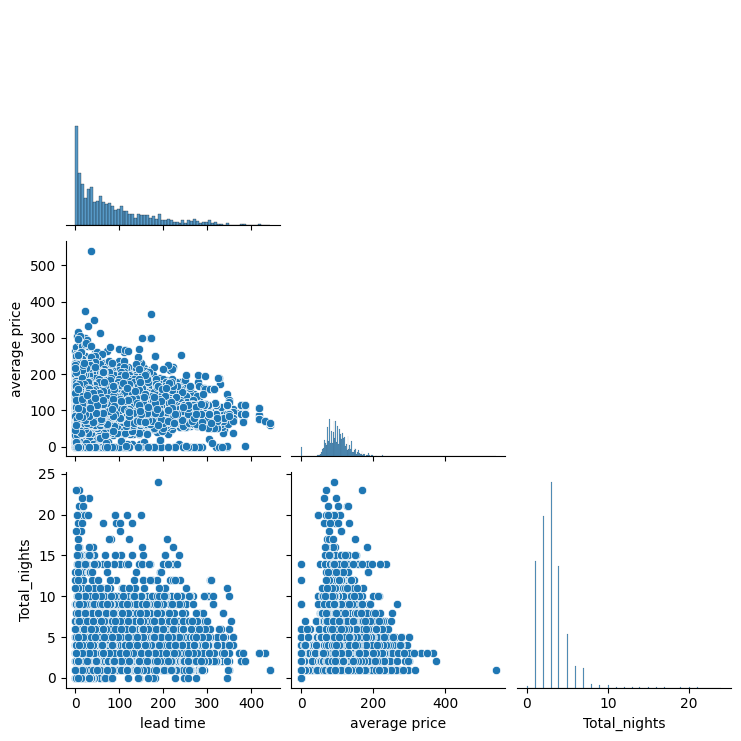

In [13]:
sns.pairplot(data[['lead time', 'average price', 'Total_nights']],corner=True,palette='viridis')
plt.show()

<ipython-input-14-47a94bf5a71e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room type', data=data,palette='viridis')


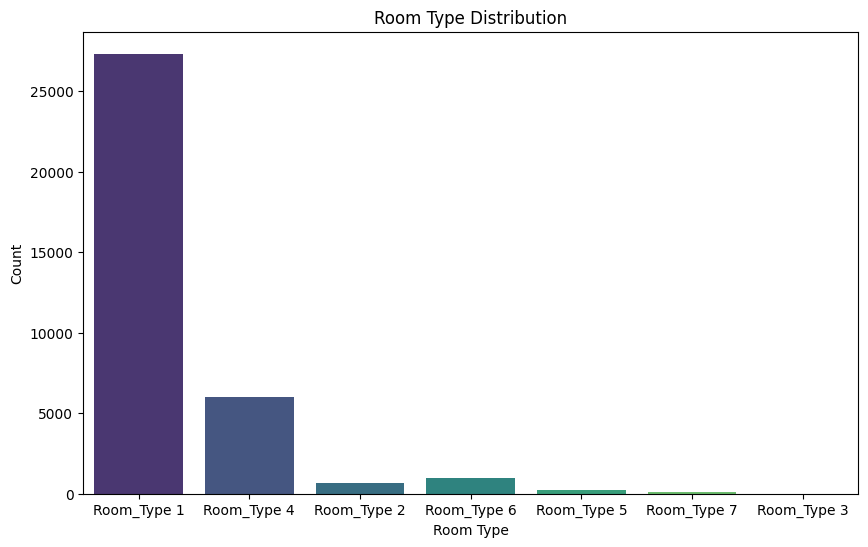

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='room type', data=data,palette='viridis')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.title('Room Type Distribution')
plt.show()

**As can be inferred from the graph the predomint room type is Room_type 1**

<ipython-input-15-8a821656560f>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data['average price'], bins=30, kde=True,palette='viridis')


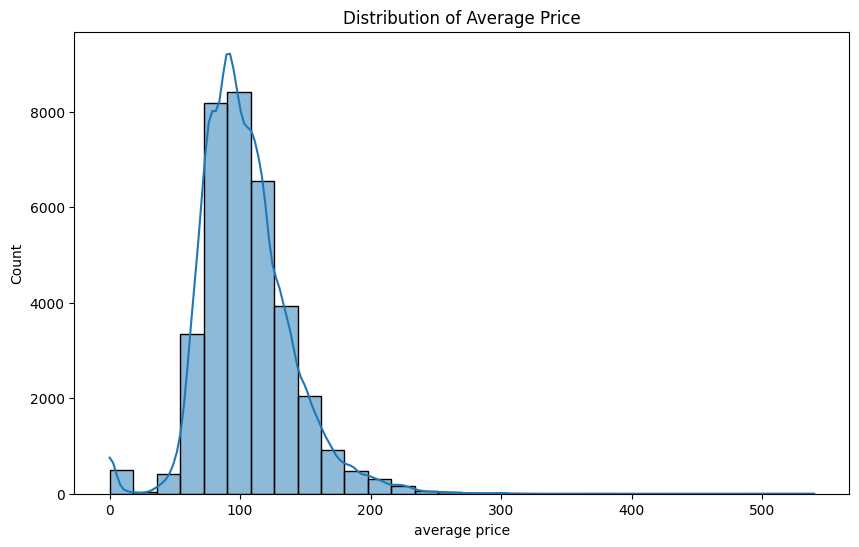

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data['average price'], bins=30, kde=True,palette='viridis')
plt.title('Distribution of Average Price')
plt.show()

**From the graph you can see that the average of all the bookings is around 100 $**

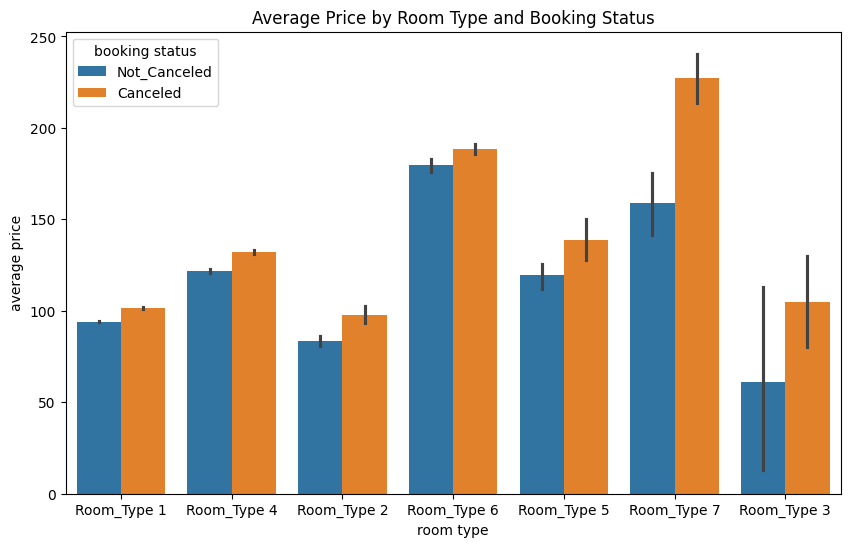

In [16]:

plt.figure(figsize=(10, 6))
sns.barplot(x='room type', y='average price', hue='booking status', data=data)
plt.title('Average Price by Room Type and Booking Status')
plt.show()

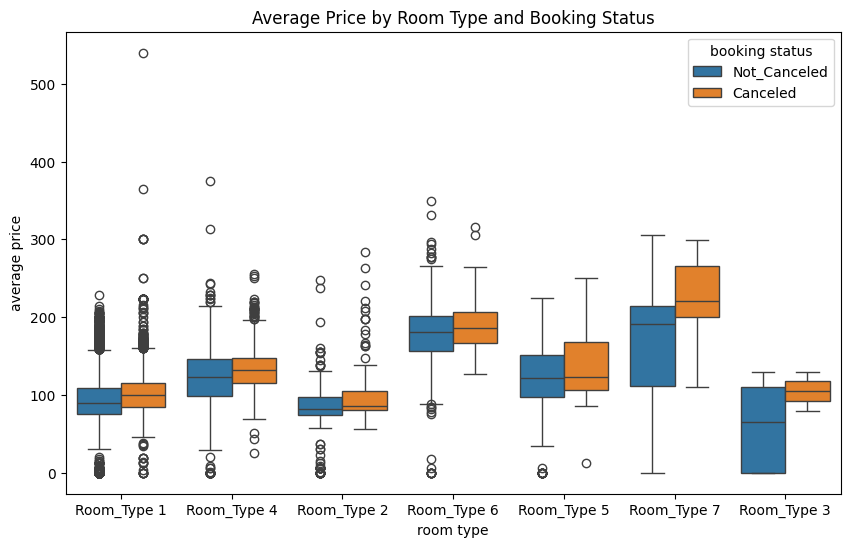

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='room type', y='average price', hue='booking status', data=data)
plt.title('Average Price by Room Type and Booking Status')
plt.show()

**Room_type 1 has the highest booked reservation**

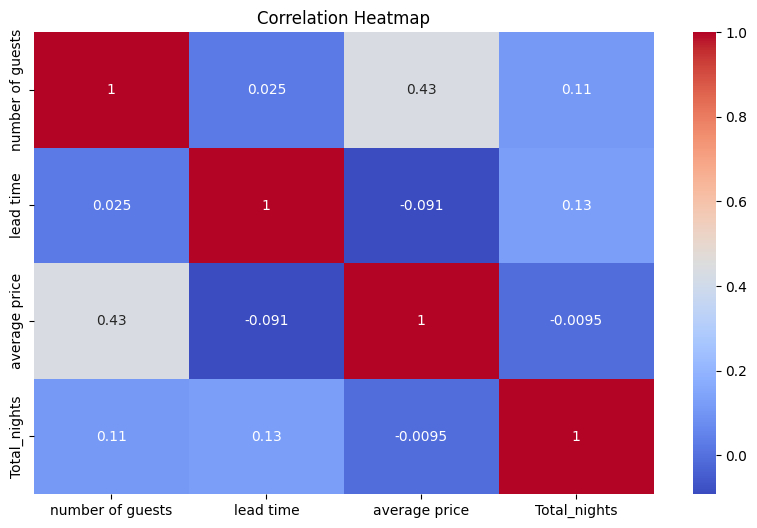

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(data[['number of guests', 'lead time', 'average price', 'Total_nights']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**There is no correlation between numerical features**

<ipython-input-19-3669972dc93b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking status', data=data, palette='viridis')


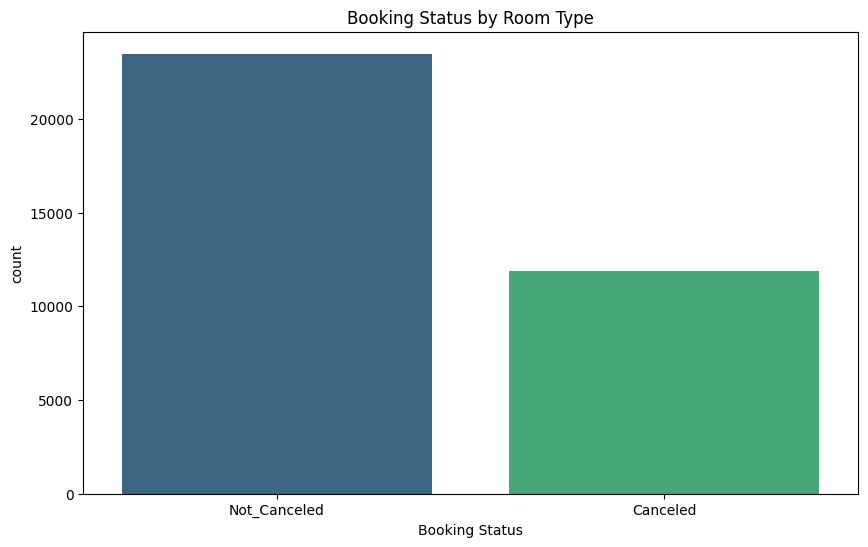

In [19]:
# prompt: compare between cancelled and confirmed booking

plt.figure(figsize=(10, 6))
sns.countplot(x='booking status', data=data, palette='viridis')
plt.xlabel('Booking Status')

plt.title('Booking Status by Room Type')
plt.show()


**The unconfirmed bookings is alomost double the confirmed**

<ipython-input-20-a482971e6921>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_bookings.index, y='Cancellation Rate', data=segment_bookings,palette='viridis')


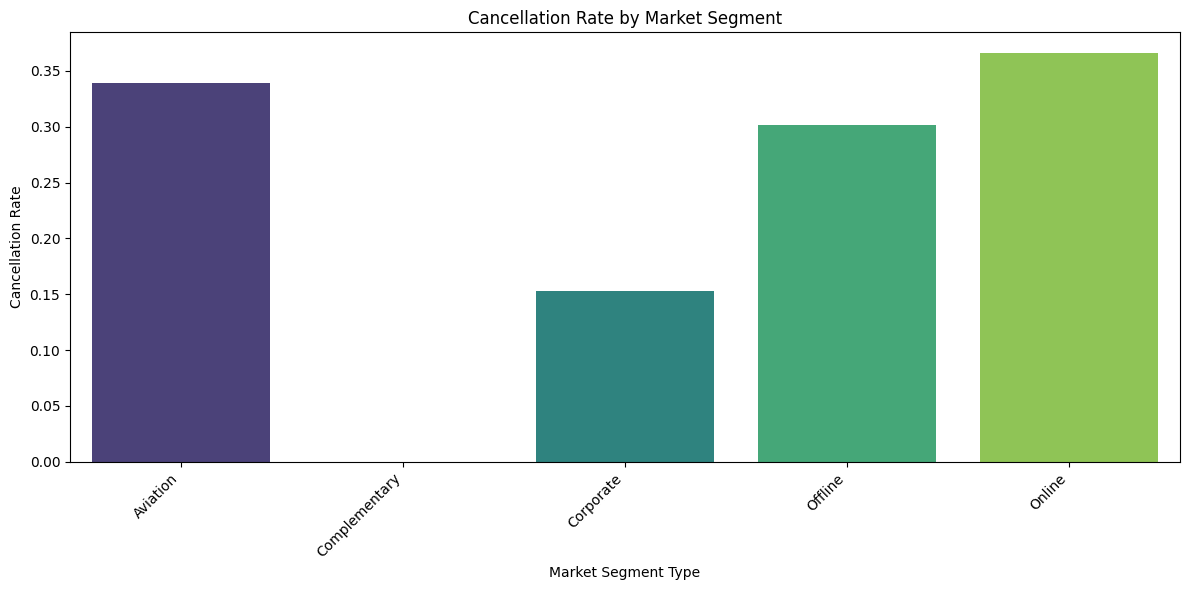

booking status       Cancellation Rate
market segment type                   
Aviation                      0.339450
Complementary                      NaN
Corporate                     0.153357
Offline                       0.301504
Online                        0.366314


In [20]:

# Group data by market segment type and booking status, count occurrences
segment_bookings = data.groupby(['market segment type', 'booking status']).size().unstack()

# Calculate the cancellation rate for each market segment
segment_bookings['Cancellation Rate'] = segment_bookings['Canceled'] / (segment_bookings['Canceled'] + segment_bookings['Not_Canceled'])

# Plotting the cancellation rate for different market segments
plt.figure(figsize=(12, 6))
sns.barplot(x=segment_bookings.index, y='Cancellation Rate', data=segment_bookings,palette='viridis')
plt.xlabel('Market Segment Type')
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Market Segment')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Print the cancellation rate for each market segment
print(segment_bookings[['Cancellation Rate']])


**This suggests that the corporate booking have the lowest cancellation rates**

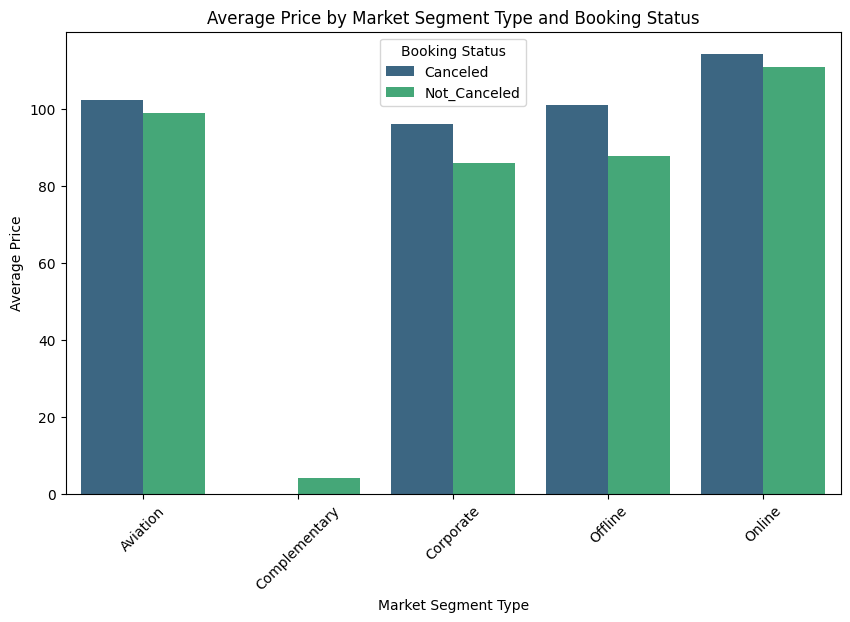

In [21]:

# Define segment_bookings (if not already defined)
segment_bookings = data.groupby(['market segment type', 'booking status'])['average price'].mean().unstack().reset_index()

# Melt the DataFrame for seaborn
segment_bookings_melted = segment_bookings.melt(id_vars='market segment type', var_name='booking status', value_name='average price')

# Plot the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='market segment type', y='average price', hue='booking status', palette='viridis', data=segment_bookings_melted)
plt.title('Average Price by Market Segment Type and Booking Status')
plt.xlabel('Market Segment Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Booking Status')
plt.show()

**This suggests that while online bookings have the highest cancellation rates they are the most profitable**